<a href="https://colab.research.google.com/github/JustinMann123/EMSC2010_Major_Assesment_JUSTINMANN/blob/main/major_assesment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem framing
My goal with this major assesment is to explore Greenland, its ice and the motion thats occuirng underneath. Greenland is home to the second largest ice sheet on the globe, and while it is well-documented that the Greenland Ice Sheet (GrIS) is losing mass at an accelerating rate, the mechanical response of the underlying bedrock remains a complex interplay of two distinct processes:

Glacial Isostatic Adjustment (GIA): The slow, long-term "rebound" of the earth from the weight of ice lost since the last Ice Age.

Elastic Deformation: The immediate, "spring-like" uplift of the crust in response to modern-day seasonal ice melt and accumulation.

The primary problem is that these two signals are affected by colinearity in GPS data. To understand the true state of Greenland’s mass balance, we need to determine if we can use data-driven Bayesian methods to isolate the modern elastic response from the long-term geological trends.


**Research Questions**

**1. Establishing Significance: Is there a link?**

Before investigating physical mechanics, we must confirm if a statistically significant relationship exists between the monthly mass fluctuations measured by GRACE and the vertical land motion (VLM) measured by the GNET GPS network. Using Bayesian correlation ($\rho$), we will test the strength of this coupling across the entire Greenland landmass.

**2. Identifying the Process: Elastic, GIA, or both?**

We need to determine which geophysical processes are driving the observed motion.If only Elastic Deformation is present: We expect a strictly linear relationship where

 $$VLM = k \times \Delta Mass$$.

** If GIA and Elastic mixing is present:** We expect to see non-linearities or offsets. Because GIA is a long-term linear "background" signal and modern ice melt is accelerating (a non-linear process), a polynomial fit (Cubic or Quartic) should outperform a simple linear model. This study will use model comparison ($az.compare$) to identify if the crustal response is purely elastic or a more complex mixture.


**3. Signal Isolation: Can we separate the "Bounce"?**

A major challenge is colinearity. The long-term trend of GIA is "baked into" the same data as the modern seasonal melt. We will investigate if detrending the datasets allows us to isolate the high-frequency seasonal "bounce" (the elastic response) from the low-frequency geological rebound (GIA).


**4. Quantifying the Response:**

The Empirical Elastic AdmittanceThe final goal is to calculate the Empirical Elastic Admittance of Greenland. This is a single value that represents the crustal sensitivity: For every Gigaton of ice lost, how many millimeters does the bedrock rise?


**5. Methodological Validation:**

Finally, we ask: Can a Bayesian regression model effectively capture this relationship? Unlike standard "best-fit" lines, the Bayesian approach allows us to maintain the integrity of the noise in the data. We will evaluate if the model can provide a high-confidence estimate (via 95% HDI) while accurately reflecting the uncertainties inherent in noisy, spatially-averaged geodetic data.






## Scope

**Scope of Study**


**Spatial Scope: **

This study utilizes an ensemble average of 61 GNET (Greenland GPS Network) stations primarily located along the coastal margins, compared against integrated mass-change data for the entire Greenland landmass.

**Temporal Scope:**

The analysis focuses on the period from 2008 to 2024. Data prior to 2008 is excluded to mitigate artifacts caused by the lower density of GPS stations in the early mission phases.

**Methodological Scope:**

 Data Transformation: GPS daily elevation is resampled to monthly means and normalized to the study period.

**Signal Processing:**

 Long-term trends (GIA + modern climate trend) will be removed (detrended) to isolate the seasonal cycle.

**Modeling:**

A Bayesian linear regression will be used to derive the "elastic admittance" coefficient, providing a probabilistic estimate of the crustal response to mass loss.

**Exclusions:**

This study does not attempt to create a spatially resolved map of uplift; instead, it treats Greenland as a single integrated system to establish a first-order relationship.

## EMSC2010 weeks leanrings i tried to incorprete into this analysis


week 2 - GitHub intergration


Week 3 - Data visualstion skills


week 4 - Data import and fair data


week 5 - Monte carlo (Used in regression)

week 8 - 	Correlation and regression

week 10 - 	Time series analysis (Fast Fourier Transform)

# Data import and cleaning/data transformation methdology

For this study two raw data files were implemtend, with a suplimentry spatial file used for plotting.


Where did the data come from
what does the data mean what is it expalin

what did i do to it methdology

and why

what are the limitaions if this link tot eh bittom say that this will be mentioned further down the line.


## FAIR DATA SECTION


**Findability (F):**

**Data Provenance**

Greenland data source:

Greenland montlhy grace mascon solutons source:


**Accessibility (A):**



**Interoperability (I):**


**Reusability (R):**

### Greenland Outline and GPS Station Locations

This section will visualize the Greenland ice sheet using gridded data from `GIS_GMB_grid.nc` and overlay the GPS station locations from `GNET_2025.nc` on a `cartopy` map.

In [17]:
!pip install cartopy
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 16.0 MB/s eta 0:00:00


**Open and explore dataset, understanding the varables ect**

In [3]:
print('--- Dataset: GIS_GMB_basin.nc ---')
ds_basin = xr.open_dataset('/content/GIS_GMB_basin.nc')
print(ds_basin)
print('\n--- Variable Information for GIS_GMB_basin.nc ---')
ds_basin.info()



print('--- Dataset: GNET_2025.nc ---')
ds_gnet = xr.open_dataset('/content/GNET_2025.nc')
print(ds_gnet)
print('\n--- Variable Information for GNET_2025.nc ---')
ds_gnet.info()


print('--- Dataset: GIS_GMB_grid.nc ---')
ds_grid_new = xr.open_dataset('/content/GIS_GMB_grid.nc')
print(ds_grid_new)
print('\n--- Variable Information for GIS_GMB_grid.nc ---')
ds_grid_new.info()

--- Dataset: GIS_GMB_basin.nc ---


NameError: name 'xr' is not defined

**Inital exploration of data. Additionally, checking that the GRACE data is correct (only one timestamp) and the GNET GNSS stations are all wihtin the bounds of greenland**


good visualiation for the readed to conceptualise what the data looks like

In [20]:
import xarray as xr
import pandas as pd
import numpy as npays
import matplotlib.pyplot as plt #for plotting
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import cartopy.crs as ccrs
import bambi as bmb

ds_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')

# Access the 'units' attribute of the 'dm' variable
dm_units = ds_grid['dm'].attrs.get('units')

print(f"The units of the 'dm' variable in GIS_GMB_grid.nc are: {dm_units}")

The units of the 'dm' variable in GIS_GMB_grid.nc are: kg/m^2


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


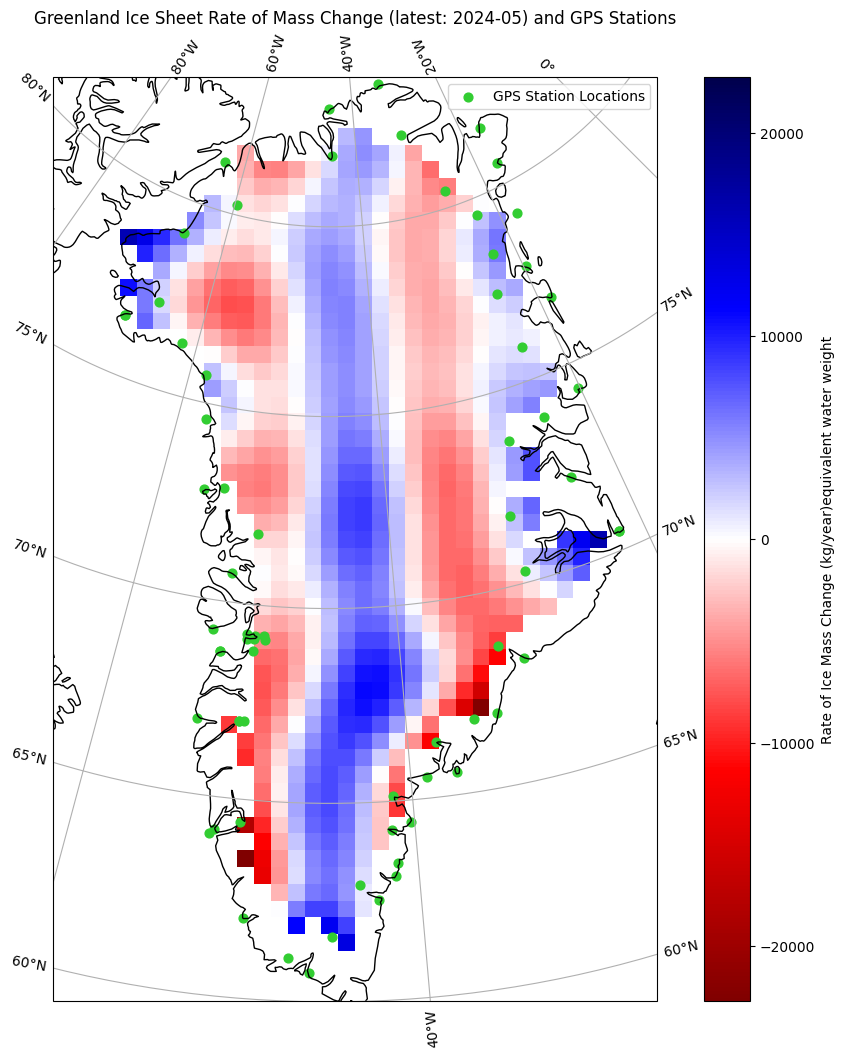

<xarray.DataArray 'dm' (y: 55, x: 36)> Size: 16kB
[1980 values with dtype=float64]
Coordinates:
  * y        (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * x        (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
    time     datetime64[ns] 8B 2002-04-18
Attributes:
    actual_range:   [-12610.9   9044. ]
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2
<xarray.DataArray 'dm' (y: 55, x: 36)> Size: 16kB
[1980 values with dtype=float64]
Coordinates:
  * y        (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * x        (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
    time     datetime64[ns] 8B 2024-05-16T12:00:00
Attributes:
    actual_range:   [-12610.9   9044. ]
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2


In [5]:

# Load the datasets (re-loading to ensure they are in scope for this cell)
grace_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')
gnet = xr.open_dataset('/content/GNET_2025.nc')

# Prepare grid data for plotting: calculate the rate of mass change (dm/dt)
# The .diff('time') reduces the 'time' dimension by 1. We then select the last available time slice.
rate_of_mass_change = (grace_grid.dm.diff('time') / (grace_grid.time.diff('time').dt.days / 365.25))

# Select the last time step for plotting the current rate of change
latest_rate_data = rate_of_mass_change.isel(time=-1)

# Create a figure and axes with the appropriate Cartopy projection
plt.figure(figsize=(12, 12))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# Plot the gridded mass change rate data
# We use pcolormesh to plot the 2D gridded data
latest_rate_data.plot.pcolormesh(
    ax=ax,
    x='x', y='y',
    transform=ccrs.NorthPolarStereo(central_longitude=-45), # The data's projection
    cmap='seismic_r',
    cbar_kwargs={'label': f'Rate of Ice Mass Change (kg/year)equivalent water weight'},
    add_colorbar=True
)

# Add geographical features
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Plot station locations from GNET_2025.nc
# Check if 'lat' and 'lon' exist in ds_gnet
if 'lat' in gnet.variables and 'lon' in gnet.variables:
    ax.scatter(
        gnet['lon'], gnet['lat'],
        transform=ccrs.PlateCarree(), # Stations are in lat/lon, so use PlateCarree for source coordinates
        color='limegreen', s=40, label='GPS Station Locations' # Changed 'neonGreen' to 'limegreen'
    )
    plt.legend()
else:
    print("Latitude and Longitude variables not found in GNET_2025.nc")

# Set title, reflecting the rate and the time of the latest data point
plt.title(f'Greenland Ice Sheet Rate of Mass Change (latest: {latest_rate_data.time.dt.strftime("%Y-%m").values}) and GPS Stations')

plt.show()



### show first and last grace signal
print(grace_grid.dm.isel(time=0))
print(grace_grid.dm.isel(time=-1))

**Exploring the raw GNET data, allowing me to understand diffrent periods of GNSS stations**




**The first step**: after knowng that GRACE data (date tiem 64) used a diffrent time comapred to the GNET data(decimal date) i needed to change all sattion time varibles to match GRACE.



**Second step** The GNET data was recorded before the launch of the GRACE mission. As a reuslt of this it was required to slice the GNET data to match the GRACE data. this was completed by simply assigning start and end date. this was done usuing a common index that could be used for all slicing and plotting purposes. this newly sliced data was saved into a new array.




**Third step** Due to GNETT instruments being sampled daily while grace is often measured monthly (noting this as a limitaion as the temporal varability of GRACE being lost due to it taking a month to sample the whole globe) I decided to to resample the daily measurmens taking the avg month mean of all daily measuremnt adn saving this into a new array.



**lastly** i plotted this data to ensure that the procces completed aove were done correctly

265


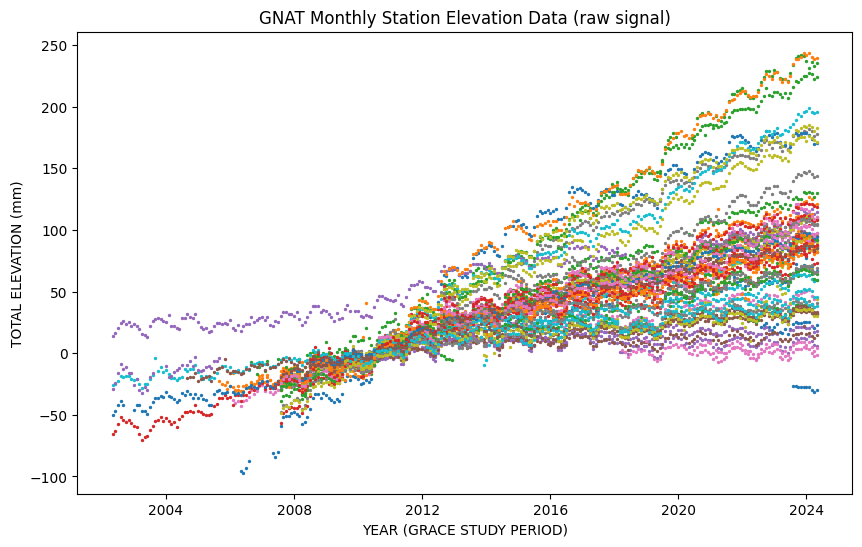

In [6]:
#### plotting raw GNET data
##AI assited with this

## what needs to be done

#Step 1

#open dataset

gnet = xr.open_dataset('/content/GNET_2025.nc')

# step 2 isolate variables

time     = pd.to_datetime(gnet['time'].values)
up       = gnet['up'].values
stations = gnet['station'].values

grace_time_values = grace_grid['time'].values
grace_time_min = pd.to_datetime(grace_time_values).min()
grace_time_max = pd.to_datetime(grace_time_values).max()


# clean data to match grace data
##look at previous cell for print function
### start 2002-04-18 End 2024-05-16

study_start = grace_time_min
study_end   = grace_time_max

### set a common index
time_index = pd.date_range(study_start, study_end, freq='MS')

### create a new array- for deomstration of what raw data looks like

unormalised = []

## this part is hard as not all of data satrt at the same time and there are 61 diffret GPS stations
## for this reason a loop function needed to be used to loop throught and trim anything out of these bounds

for i, stn in enumerate(stations):
    # (a) slice to GRACE period
    series = pd.Series(up[i], index=time)
    series = series[(series.index >= study_start) & (series.index <= study_end)]

## need to resample the daily measurments to avg monthly as we daily is very noisy--Limitation?

    monthly_Unormalised = series.resample("MS").mean()

### Figure out what this is doing i dare say this is staring them all somwhere??
    monthly1_Unormalised = monthly_Unormalised.reindex(time_index)

#### save into the array

    unormalised.append(monthly1_Unormalised.values)

unormalised_array = np.array(unormalised)

#### with new array created that contians all gnet station monthly elevation data within study periods
#### plot to show for the A3 poster
### this is also hard as there are 61 stations dat that needs to be plotted on that graph
## therfore we need to do a loop plt.scatter

plt.figure(figsize=(10, 6))
for i, stn_data in enumerate(unormalised_array):
  plt.scatter(time_index, stn_data,s=2)
  plt.xlabel('YEAR (GRACE STUDY PERIOD)')
  plt.ylabel('TOTAL ELEVATION (mm)')
  plt.title('GNAT Monthly Station Elevation Data (raw signal)')

print(len(time_index))

# Normalisation

how do you expalin this and why it was done

****

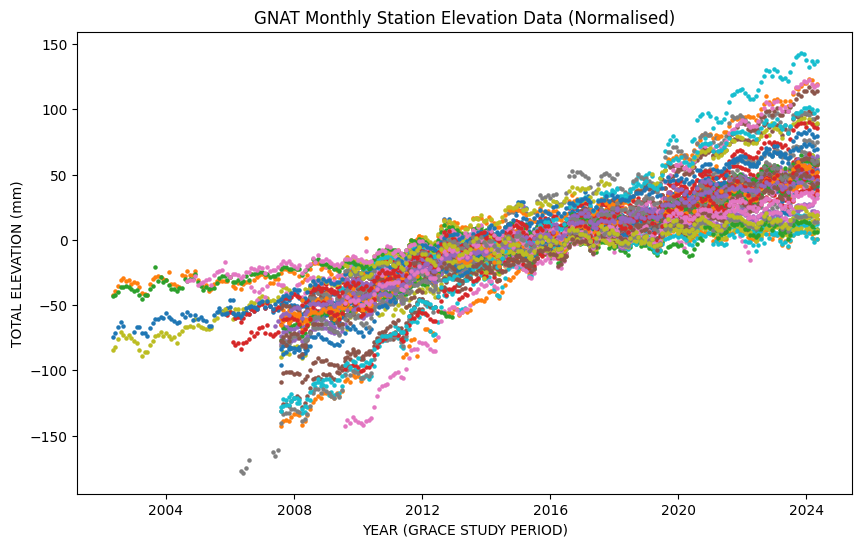

In [7]:
### Simular to the last step but wiht extra step involved

normalised = []

for stn_unnormalised_data in unormalised_array:
  # Convert the numpy array back to a Series for easy use of .dropna() and .mean()
  current_monthly_unnormalised = pd.Series(stn_unnormalised_data, index=time_index)

#### this is to get rid of gp stations that only collected data for less than x months. this cna be removed
  if current_monthly_unnormalised.dropna().__len__() < 60:
    continue # Now 'continue' is inside a loop

  normalised_gnet = current_monthly_unnormalised - current_monthly_unnormalised.mean()
  normalised.append(normalised_gnet.values)

normalised_array = np.array(normalised)
### do we want to get rid of all data that is less than say 3 years ?
# or only include data that spans the entire period

plt.figure(figsize=(10, 6))
for i, stn_data in enumerate(normalised_array):
  plt.scatter(time_index, stn_data,s=5)
  plt.xlabel('YEAR (GRACE STUDY PERIOD)')
  plt.ylabel('TOTAL ELEVATION (mm)')
  plt.title('GNAT Monthly Station Elevation Data (Normalised)')

In [ ]:
print(gnet.data_vars)

Data variables:
    decimalyear  (station, time) float32 3MB ...
    east         (station, time) float32 3MB ...
    north        (station, time) float32 3MB ...
    up           (station, time) float32 3MB nan nan nan nan ... nan nan nan nan
    east_error   (station, time) float32 3MB ...
    north_error  (station, time) float32 3MB ...
    up_error     (station, time) float32 3MB ...
    lat          (station) float32 280B ...
    lon          (station) float32 280B ...
    height       (station) float32 280B ...


## convert normalised data to an averaged elastic and GIA rate. ie a rate hopfully representaive of the entire grrenland land mass.




note massive limition of doing this you remove all spatial varabilty ect

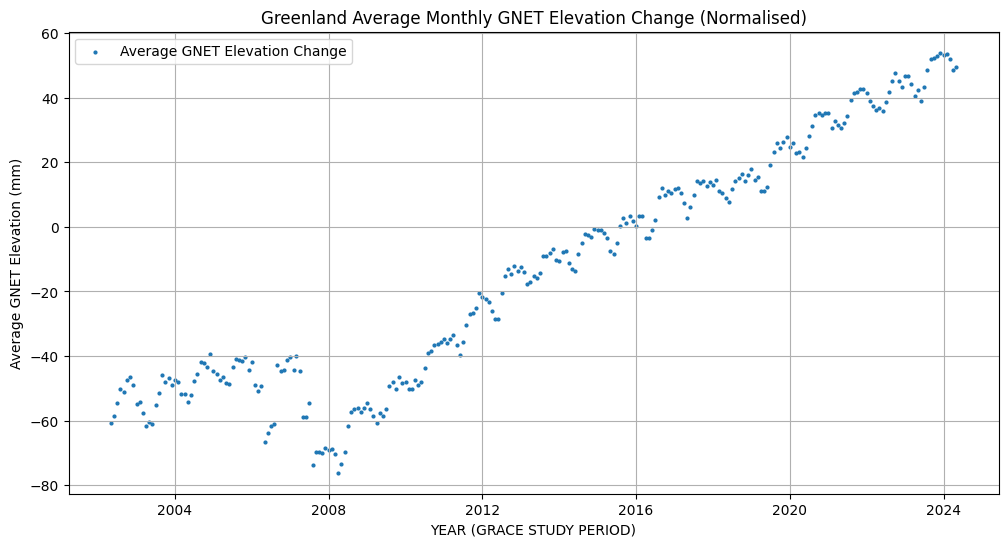

265


In [8]:
#### need to take the normalised data and take the greenland avg.
## once agin need a loop function to each indavidual time preiod ie all gps
## measurments for 2004-04-1 take the avg
### pretty sure this is called an esembel mean


# Calculate the mean elevation across all normalised GNET stations for each time step
# `normalised_array` is (num_stations, num_time_steps)
# We want to average across the first dimension (stations)


mean_gnet_elevation = np.nanmean(normalised_array, axis=0)

plt.figure(figsize=(12, 6))
plt.scatter(time_index, mean_gnet_elevation, marker='o', linestyle='-', s=4, label='Average GNET Elevation Change')
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Average GNET Elevation (mm)')
plt.title('Greenland Average Monthly GNET Elevation Change (Normalised)')
plt.grid(True)
plt.legend()
plt.show()

print(len(mean_gnet_elevation))


**Why are we observing this significant decrease in average elevation across Greenland?**

Greenland's GNET system was relatively new during the early 2000s, resulting in limited station data, as depicted in the preceding plots. Furthermore, Greenland does not deform uniformly. Different regions experience varying rates of elastic deformation, leading to localized uplift or subsidence as they lose or gain ice mass annually. In addition, Glacial Isostatic Adjustment (GIA) is occurring, presumably at a relatively steady rate across Greenland. Therefore, the observed decrease in average elevation prior to 2008 is likely an artifact. This is attributable to both the scarcity of early GNET data and the averaging process, which diminishes the spatial resolution across Greenland. For the remainder of the analysis, all GNET and GRACE data prior to 2008 will be excluded to mitigate the influence of this data artifact.

Data variables:
    time_dec  (time) float64 2kB ...
    lon       (y, x) float64 16kB ...
    lat       (y, x) float64 16kB ...
    dm        (time, y, x) float64 4MB ...
    area      (y, x) float64 16kB ...
    crs       |S1 1B ...


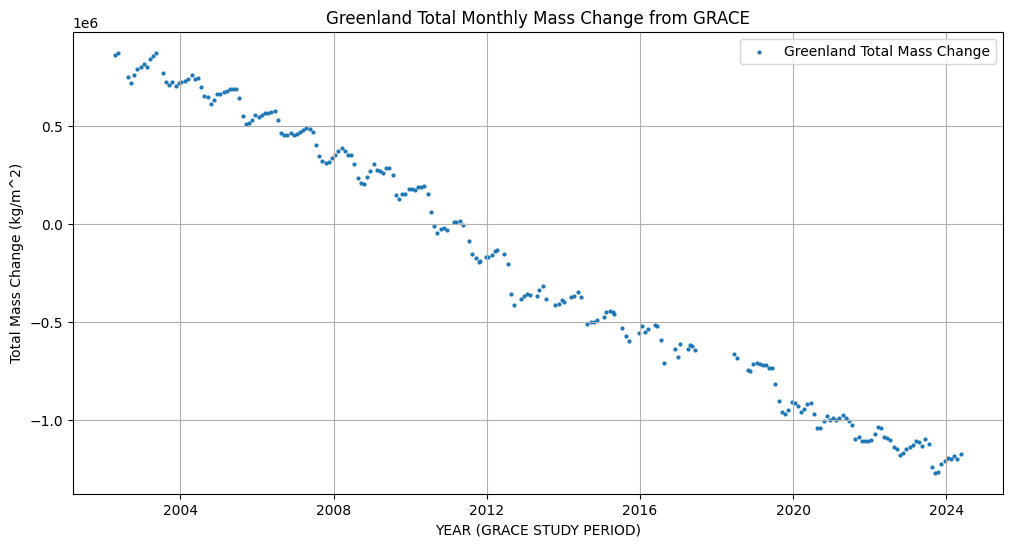

233


In [9]:
grace_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')

### have to implmet the same loop function to sample monthly mean mass change across all mascons
print(grace_grid.data_vars)
grace_grid.dm

grace_mass = grace_grid['dm'].values
grace_time = grace_grid['time'].values

time_series = []
for t in range(grace_mass.shape[0]):
    kgm2 = grace_mass[t, :, :]
    time_series.append(np.nansum(kgm2)) ## i think beceause there are periods where grace wasnt observing you need to add NAN to this. didnt work wihtout!


plt.figure(figsize=(12, 6))
plt.scatter(grace_time, time_series, marker='o', linestyle='-', s=4, label='Greenland Total Mass Change')
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Total Mass Change (kg/m^2)')
plt.title('Greenland Total Monthly Mass Change from GRACE')
plt.grid(True)
plt.legend()
plt.show()

print(len(time_series))

### Confirming GNET Time Range Alignment and Exporting Formatted Data

First, let's confirm the time range used for the GNET averaged data aligns with the GRACE data. Then, we will prepare both datasets for export, ensuring their time indices are uniformly formatted to 'month/year'.

In [34]:
import pandas as pd
import numpy as np

# --- 1. Confirm GNET time range alignment with GRACE ---

# Grace min/max dates (from kTI6jCRJONAo's execution)
# Ensure grace_time_values, grace_time_min, grace_time_max are in scope.
# If not, you might need to re-run cell kTI6jCRJONAo or explicitly define them again.
print(f"GRACE data start date: {grace_time_min.strftime('%Y-%m-%d')}")
print(f"GRACE data end date: {grace_time_max.strftime('%Y-%m-%d')}")

# GNET time_index min/max dates (from kTI6jCRJONAo's execution)
print(f"GNET data time_index start date: {time_index.min().strftime('%Y-%m-%d')}")
print(f"GNET data time_index end date: {time_index.max().strftime('%Y-%m-%d')}")

# --- 2. Process GRACE data for CSV export ---

# Recreate grace_series (if not in scope or to ensure freshest version)
# grace_mass and grace_time should be from cell R1KBoEuDbsNK
total_grace_mass_change = [np.nansum(grace_mass[t, :, :]) for t in range(grace_mass.shape[0])]
grace_series = pd.Series(total_grace_mass_change, index=pd.to_datetime(grace_time))

# Resample GRACE data to a monthly start frequency and take the mean
grace_monthly_resampled = grace_series.resample('MS').mean()

# --- 3. Process GNET data for CSV export ---

# mean_gnet_elevation and time_index should be from cell LaLZiEa7ctru and kTI6jCRJONAo
gnet_monthly_series = pd.Series(mean_gnet_elevation, index=time_index)

# --- 4. Align both series to a common time index for export ---
common_index = gnet_monthly_series.index.intersection(grace_monthly_resampled.index)

grace_aligned_for_csv = grace_monthly_resampled.reindex(common_index)
gnet_aligned_for_csv = gnet_monthly_series.reindex(common_index)

# --- 5. Format dates to 'month/year' and export to CSV ---

# Create a DataFrame for export
final_export_df = pd.DataFrame({
    'GRACE_Total_Mass_Change': grace_aligned_for_csv.values,
    'GNET_Avg_Elevation': gnet_aligned_for_csv.values
}, index=grace_aligned_for_csv.index.strftime('%Y-%m'))

# Name the index column
final_export_df.index.name = 'Month_Year'

# Save to CSV file
output_filename = 'aligned_grace_gnet_monthly.csv'
final_export_df.to_csv(output_filename)

print(f"\nFormatted and aligned data saved to '{output_filename}'")
display(final_export_df.head())

GRACE data start date: 2002-04-18
GRACE data end date: 2024-05-16
GNET data time_index start date: 2002-05-01
GNET data time_index end date: 2024-05-01

Formatted and aligned data saved to 'aligned_grace_gnet_monthly.csv'


,GRACE_Total_Mass_Change,GNET_Avg_Elevation
Month_Year,,
2002-05,869341.5,-60.875069
2002-06,NaN,-58.688957
2002-07,NaN,-54.523087
2002-08,746172.2,-50.238350
2002-09,715305.4,-51.190781


##**PART 1 of the analysis**


**Is there a statistically significant correlation between Greenland GPS vertical uplift and GRACE ice mass loss**

In [37]:
alligned_grace_gnet = pd.read_csv('aligned_grace_gnet_noNAN_monthly.csv')
print(alligned_grace_gnet.head())

  Month_Year  GRACE_Total_Mass_Change  GNET_Avg_Elevation
0    2008-01                 349034.1           -69.01331
1    2008-02                 371748.7           -68.87524
2    2008-03                 383408.4           -70.48487
3    2008-04                 370593.4           -76.17806
4    2008-05                 348870.3           -73.51562


In [38]:
gnet_nan_removed = alligned_grace_gnet['GNET_Avg_Elevation']
grace_nan_removed = alligned_grace_gnet['GRACE_Total_Mass_Change']

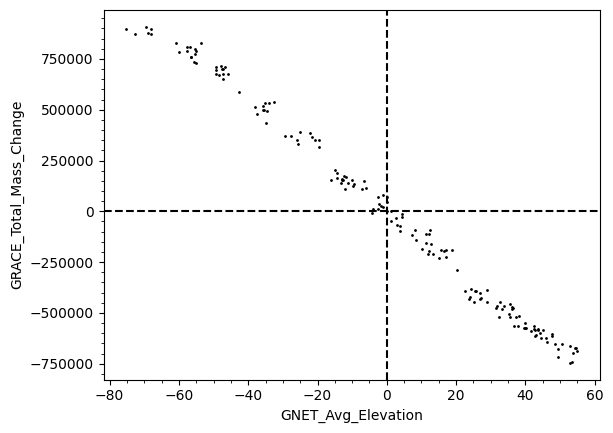

In [41]:
x = gnet_nan_removed - np.mean(gnet_nan_removed) #deviation in the x variable
y = grace_nan_removed - np.mean(grace_nan_removed) #deviation in the y variable
plt.plot(x,y,'ok',markersize=1) #plot the deviations
plt.gca().axvline(x=0, color = 'k', linestyle = '--') #add a vertical line at x=0
plt.gca().axhline(y=0, color = 'k', linestyle = '--') #add a horizontal line at y=0
plt.xlabel('GNET_Avg_Elevation') #label the x-axis
plt.ylabel('GRACE_Total_Mass_Change') #label the y-axis
plt.minorticks_on() #include minor ticks

In [42]:
num = np.sum(x*y) #find the numerator
den = np.sqrt(np.sum(x**2)) * np.sqrt(np.sum(y**2)) #find the denominator
r = num/den #obtain r
print('Sample correlation r = {:.2f}'.format(r)) #print result to 2 d.p.

Sample correlation r = -1.00


**what does this mean? can we continue?**

just simply exaplin what it means, what more can we do?

In [43]:
import pymc as pm #for automated Bayesian inference
import arviz as az #for analysis of Bayesian models
data = np.column_stack([ gnet_nan_removed, grace_nan_removed])   #form a variable with dist in the first column and gs in the second column (this is needed by PyMC)

with pm.Model() as model: #define the PyMC model

    # Priors for means of the bivariate normal distribution
    mu = pm.Normal("mu", mu=0, sigma=5, shape=2)

    # Prior for correlation coefficient — uniform between -1 and 1
    rho = pm.Uniform("rho", lower=-1, upper=1)

    # Prior for standard deviations of the bivariate normal distribution
    sigma = pm.HalfNormal("sigma", sigma=2, shape=2)

    # Build the covariance matrix from rho and sigmas
    cov = pm.math.stack([
        [sigma[0]**2, rho * sigma[0] * sigma[1]],
        [rho * sigma[0] * sigma[1], sigma[1]**2             ]
    ])

    # Likelihood is a "multivariate" (in this case bivariate) normal distribution
    obs = pm.MvNormal("obs", mu=mu, cov=cov, observed=data)

    # Obtain 5000 samples from the posterior distributions (mu, rho, & sigma)
    trace = pm.sample(sample=5000)

Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,-0.099,0.005,-0.109,-0.089,0.0,0.0,960.0,1041.0,1.0


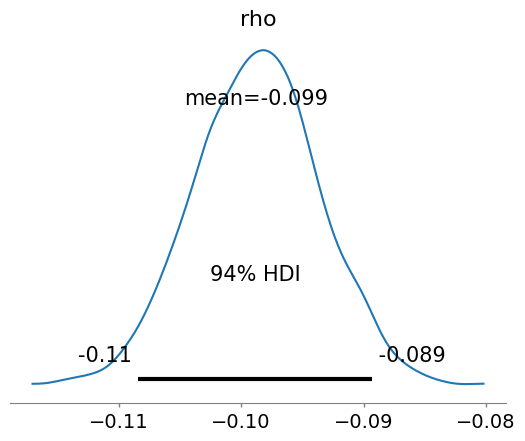

In [44]:
az.plot_posterior(trace, var_names=["rho"])
az.summary(trace, var_names=["rho"], hdi_prob=0.95)

**How many mm of bedrock uplift accompanies each unit of ice mass lost, and is the relationship linear?**

In [45]:
data = pd.DataFrame({"x": gnet_nan_removed, "y": grace_nan_removed}) #put the data into a dataframe with variable names "x" and "y".
model = bmb.Model("y ~ x", data) #setup the first-order polynomial model
idata = model.fit(draws=2000, tune=2000, chains=8) #sample the posteriors using the markov monter carlo proccess

Output()

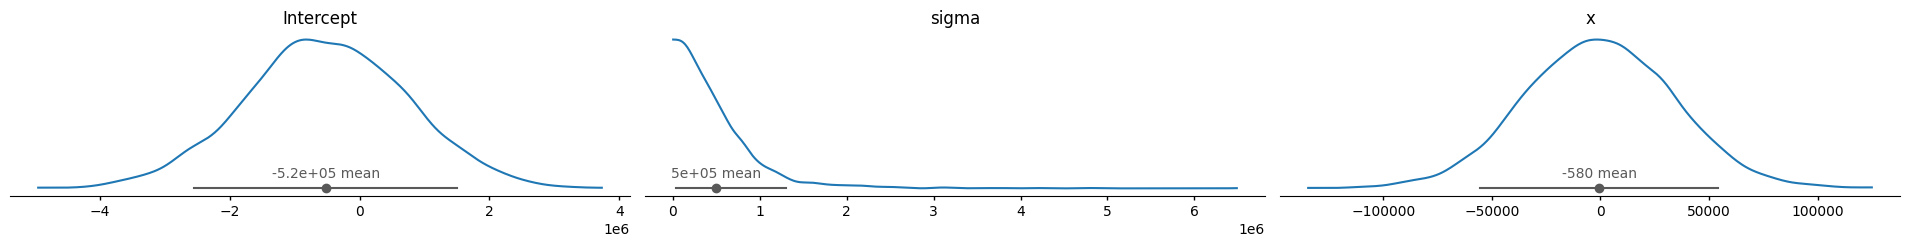

In [46]:
model.plot_priors()
plt.tight_layout()
plt.show()

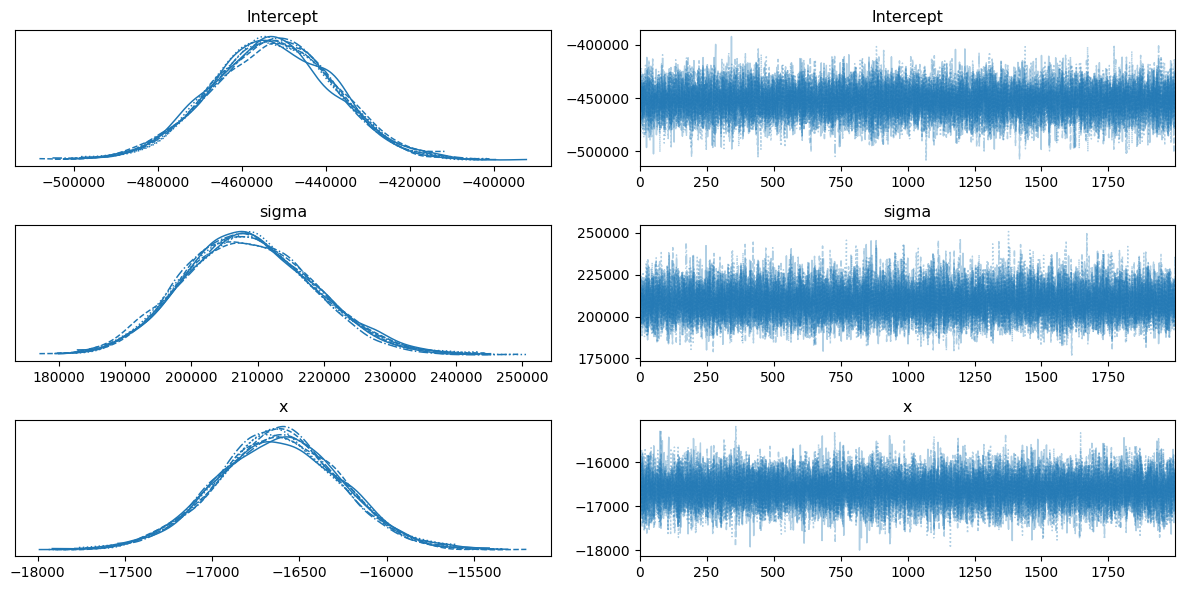

In [23]:
az.plot_trace(idata);
plt.tight_layout() #this spaces the plots out so that they don't overlap

/tmp/ipykernel_2752/3141278588.py:13: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_mean_draws, hdi_prob=0.95)


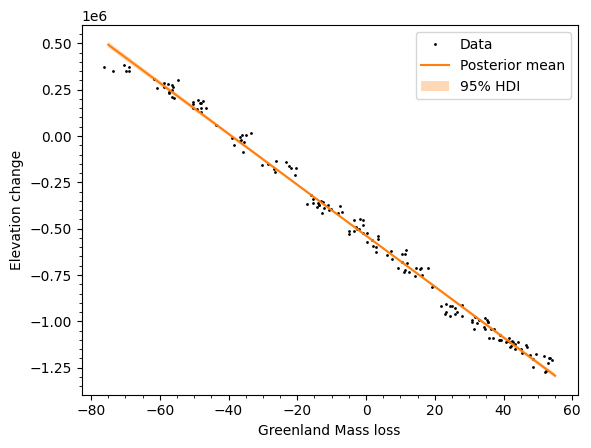

In [48]:
x_range = np.linspace(-75, 55, 100) # Predict across a range of x values from 1 to 11
new_data = pd.DataFrame({"x": x_range}) #dataframe with the new x-values
model.predict(idata, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Compute posterior mean and HDI at each x point
posterior_mean = y_mean_draws.mean(axis=0)
hdi = az.hdi(y_mean_draws, hdi_prob=0.95)



# Plot the results
plt.plot(gnet_nan_removed, grace_nan_removed, 'ok', label="Data", markersize= 1)
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
plt.xlabel('Greenland Mass loss')
plt.ylabel('Elevation change')
plt.legend()
plt.minorticks_on()

**What does this mean?**

##**PART 2 of the Analysis**

**What is that relationship and is it consistent with elastic deformation theory?**

**what is Elastic deformation theory, you ask?**
"Elastic deformation theory describes the temporary, reversible change in a material's shape or size when subjected to external forces". To conceptulise what elastic deforamtion means in teh context of greenland we must think about what is happenign. Greenalnd revves large amount of perciptioan in the form snowfall, this occurs annually but mostly in autumn and winter months. During summer we also have large amounts of sublimation and melting of the ice. To make matters worse cliamte change is only exacerbating the melt meaning greenland has less and less mass each year. elastically thinking I hypothesies that we greenland should

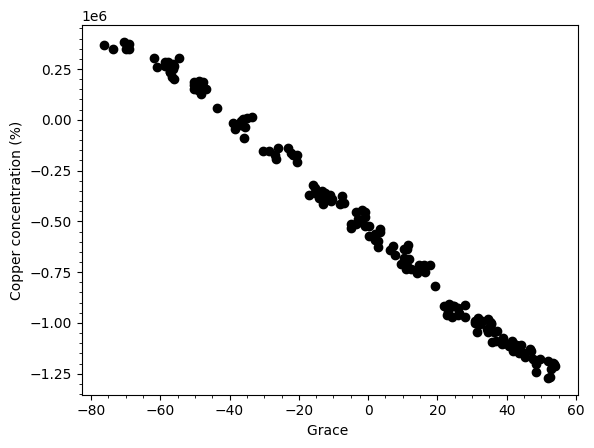

In [47]:
### i think this is the code i will use for this

plt.plot(gnet_nan_removed, grace_nan_removed,'ok')
plt.xlabel('Grace ')
plt.ylabel('Copper concentration (%)')
plt.minorticks_on()

In [49]:
data = pd.DataFrame({"y": grace_nan_removed}) #define the y-variable
data["x_scaled"] = (gnet_nan_removed-np.mean(gnet_nan_removed)) / np.std(gnet_nan_removed) #scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression

In [50]:
# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True})

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True})

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True})

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True})

Output()

Output()

Output()

Output()

In [51]:
# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
})
print(comparison) #print the result

           rank     elpd_loo     p_loo  elpd_diff        weight        se  \
cubic         0 -1974.456725  4.593029   0.000000  9.317129e-01  8.397183   
quartic       1 -1975.392451  5.480028   0.935726  2.375646e-16  8.346159   
linear        2 -1998.336105  3.321741  23.879380  6.828709e-02  9.569071   
quadratic     3 -1999.135170  4.844068  24.678445  4.440892e-16  9.197198   

                dse  warning scale  
cubic      0.000000    False   log  
quartic    0.433420    False   log  
linear     8.427652    False   log  
quadratic  8.093529    False   log  


##**cubic ranked best polynomial fit, what does this mean?**

talk about what this means start to mention GIA and what may be occuring

**Can we Estimate the amount of defomation rate/GT of mass loss/gain?**

**What could we do**


i think we use FFT if so mention wha tmight be better used for this also mentioning limitations ect

or if we find somthign like the fft then we cna use that instead.


##**PART 3 of the Analysis**


**Can we separate elastic from GIA, if so can we infer how much mass it requires to deform greenland?**

In [ ]:
## using fft to try and isolate elastic from GIA



## Conclusion

## Limitations

##Fair Data-- METTA DATA

**Provenance.**

Where did this data originate? (e.g., specific satellites like Landsat 8 or climate models like Carbonator).

**Lineage**

What steps did you take to process the raw data? (e.g., "Clipped the study area to 30MB," "Applied a contrast stretch," or "Used a supervised classification algorithm").

**Accuracy & Error**

What are the limitations? (e.g., Landsat 8 has a 65m horizontal accuracy, or specific classes like "Heath" might be misclassified as "Grassland").

**Technical Specs**

What is the resolution? (e.g., "30m x 30m pixels") and what do the specific "bands" represent? (e.g., Band 5 for Near-Infrared/Biomass).

# Reflection

Part 2 - Individual reflection (10%)

Your notebook must include a personal reflection of up to 500 words.

This reflection should focus on your decision-making and learning process. Possible topics include:

your motivation for selecting the project topic,
unexpected challenges you encountered,
changes you made to your project due to data or methodological limitations, and
what you consider to be the key strengths and shortcomings of your final analysis.
There is no single “correct” reflection; marks are awarded for thoughtful and honest engagement.

---- motivation ----

My motivation throught this project was to build on ideas and information that i have recenlty been seeing in a class focusoing on melting polar icecaps. A big focus in this class was exploring diffrent technology and how these infastructure like satitliets GPS/GNSS ect can offer valuble data to answer geopyhsical questions. so i wanted to take some of these idea and apply them to the teachings in this semesters teachings. While this is more of a broad motivation selcting the exact topic was done after abit of data anylisis and finalsed.

---unexpected challenges you encountered-----





----Strenghts and limitations-----


some of the major strenght



there are most definntly some marjor weaknesses within the data and the analsis






# Data Science Fair

